# sPCA cell-level bootstrap: program stability (alpha=1.0, n_components=78 fixed)

For each bootstrap iteration produced by `03_spca_cell_bootstrap_worker.py` (cells resampled with
replacement to the original size within each ligand x replicate group, prior to pseudobulking
and refitting sPCA), pair each of the 78 real-data alpha=1.0 reference programs with its best
available match in that iteration. Then summarize how reproducible each reference
program is under cell-sampling noise.

This notebook does both the matching computation and the visualization (unlike the alpha
sweep, this step is cheap -- it's just reading component tables and computing similarities,
not refitting sPCA -- so there's no need for a separate headless script).

Matching is unconstrained: two reference programs that share genes may both pick the same refit
component as their best available match in a given bootstrap draw.

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['text.usetex']  = False

# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
REFERENCE_COMPONENTS = (
    f"{IMPORTS_DIR}/SIG13/analysis_outs/spca/degs_zscore_allLigands/"
    "zscore_degs_allLigands_0.1_alpha1.0_sPCA_components.csv"
)
CLEAN_COMPONENTS = (
    f"{IMPORTS_DIR}/SIG13/analysis_outs/spca/"
    "lm_fit_zscore_degs_allLigands_0.1_alpha1.0_sPCA_clean.csv"
)
BOOTSTRAP_DIR = f"{IMPORTS_DIR}/SIG13/analysis_outs/spca_stability/bootstrap"
BOOTSTRAP_OUT_DIR = f"{OUTS_DIR}/spca_stability/bootstrap"
os.makedirs(BOOTSTRAP_OUT_DIR, exist_ok=True)
COMPONENTS_DIR = f"{BOOTSTRAP_DIR}/components"
PLOT_DIR = f"{OUTS_DIR}/spca_stability/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

COLLAPSE_NORM_TOL = 1e-8
COLLISION_SIM_THRESHOLD = 0.3  # best-match cosine similarity below this = program not recovered in that iteration

In [2]:
def load_components(path):
    """Load a components CSV (gene, 0, 1, ..., n-1) sorted by gene for stable alignment."""
    df = pd.read_csv(path).sort_values("gene").reset_index(drop=True)
    genes = df["gene"].values
    mat = df.drop(columns="gene").to_numpy(dtype=np.float64).T  # components x genes
    return genes, mat


def match_to_reference(ref_genes, ref_mat, genes, mat):
    """Best available (unconstrained) match of each reference program to a query fit.

    Each reference program is paired with whichever query component it is most similar to;
    several reference programs may share the same best-matching component.
    """
    if not np.array_equal(ref_genes, genes):
        common = np.intersect1d(ref_genes, genes)
        ref_idx = {g: i for i, g in enumerate(ref_genes)}
        q_idx = {g: i for i, g in enumerate(genes)}
        ref_mat = ref_mat[:, [ref_idx[g] for g in common]]
        mat = mat[:, [q_idx[g] for g in common]]

    scaler = StandardScaler()
    ref_mat = scaler.fit_transform(ref_mat.T).T
    mat = scaler.fit_transform(mat.T).T

    ref_norm = np.linalg.norm(ref_mat, axis=1)
    q_norm = np.linalg.norm(mat, axis=1)

    sim = cosine_similarity(ref_mat, mat)
    ref_ind = np.arange(sim.shape[0])

    best_available_component = np.argmax(sim, axis=1)
    best_available_similarity = sim[ref_ind, best_available_component]

    return pd.DataFrame(
        {
            "ref_component": ref_ind,
            "ref_component_collapsed": ref_norm < COLLAPSE_NORM_TOL,
            "best_available_component": best_available_component,
            "best_available_similarity": best_available_similarity,
            "best_available_component_collapsed": q_norm[best_available_component] < COLLAPSE_NORM_TOL,
        }
    )

In [3]:
ref_genes, ref_mat = load_components(REFERENCE_COMPONENTS)

iter_files = sorted(glob.glob(f"{COMPONENTS_DIR}/bootstrap_iter*_sPCA_components.csv"))
print(f"Found {len(iter_files)} completed bootstrap iterations in {COMPONENTS_DIR}")

records = []
for path in iter_files:
    iter_id = int(os.path.basename(path).split("bootstrap_iter")[1][:4])
    genes, mat = load_components(path)
    matched = match_to_reference(ref_genes, ref_mat, genes, mat)
    matched.insert(0, "iteration", iter_id)
    records.append(matched)

matched_long = pd.concat(records, ignore_index=True)
matched_long.to_csv(f"{BOOTSTRAP_OUT_DIR}/matched_similarity_long.csv", index=False)
matched_long.head()

Found 2000 completed bootstrap iterations in /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/spca_stability/bootstrap/components


,iteration,ref_component,ref_component_collapsed,best_available_component,best_available_similarity,best_available_component_collapsed
0,0,0,False,0,0.835424,False
1,0,1,False,1,0.988997,False
2,0,2,False,2,0.968337,False
3,0,3,False,3,0.889831,False
4,0,4,False,4,0.985403,False


In [4]:
# per-program stability summary across bootstrap iterations
stability = matched_long.groupby("ref_component")["best_available_similarity"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), min="min", max="max"
)
collision_rate = (
    matched_long.assign(collision=matched_long["best_available_similarity"] < COLLISION_SIM_THRESHOLD)
    .groupby("ref_component")["collision"]
    .mean()
    .rename("collision_rate")
)
stability = stability.join(collision_rate)
stability = stability.sort_values("median")
stability.to_csv(f"{BOOTSTRAP_OUT_DIR}/component_stability_summary.csv")

# which reference programs survived cleanup (present in CLEAN_COMPONENTS) vs. were filtered out --
# used to annotate the boxplots below
clean_component_ids = set(
    int(c.split("_")[1]) for c in pd.read_csv(CLEAN_COMPONENTS)["component"].unique()
)
matched_long["status"] = matched_long["ref_component"].map(
    lambda c: "clean" if c in clean_component_ids else "filtered"
)

stability.head(15)

,median,q25,q75,min,max,collision_rate
ref_component,,,,,,
39,0.417590,0.339195,0.559075,0.200787,0.961015,0.1455
6,0.493570,0.478991,0.512683,0.250949,0.879865,0.0070
54,0.502537,0.476019,0.530119,0.241515,0.981187,0.0030
67,0.505640,0.462976,0.630956,0.363456,0.969952,0.0000
33,0.549326,0.513742,0.621260,0.384615,0.978837,0.0000
16,0.567384,0.483374,0.660717,0.266880,0.950402,0.0030
9,0.617513,0.514603,0.814005,0.276402,0.962133,0.0005
27,0.648269,0.613028,0.689972,0.501911,0.939950,0.0000
42,0.648657,0.512297,0.831042,0.302865,0.974330,0.0000


/tmp/ipykernel_1261246/1296241405.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)


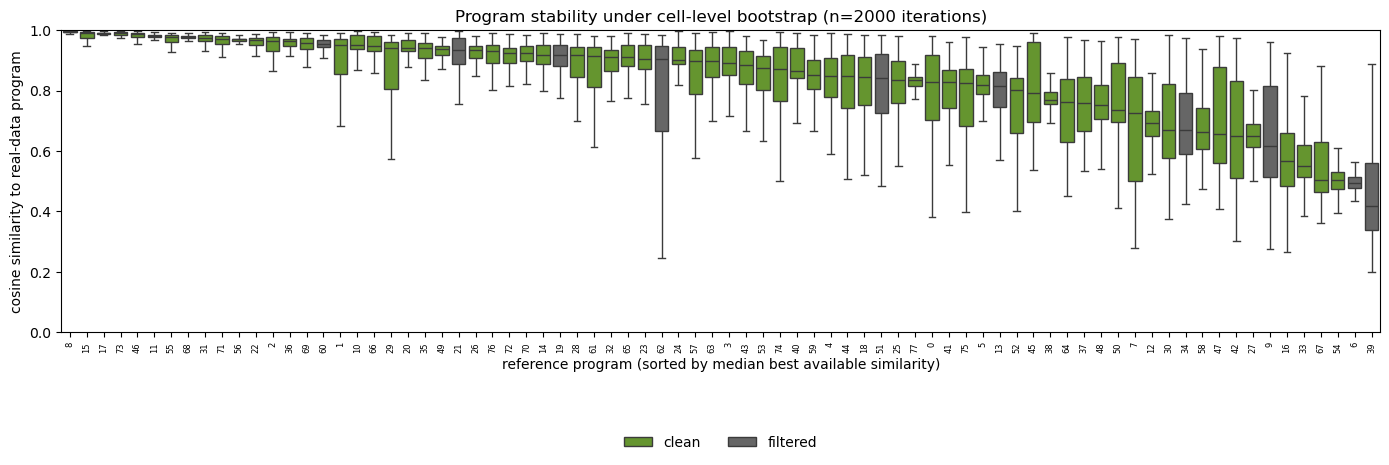

In [5]:
# box plot of best available cosine similarity per reference program, ordered by median stability
order = matched_long.groupby("ref_component")["best_available_similarity"].agg(median="median").sort_values("median", ascending=False).index.tolist()
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=matched_long,
    x="ref_component",
    y="best_available_similarity",
    order=order,
    ax=ax,
    hue="status",
    hue_order=["clean", "filtered"],
    palette={"clean": "#66a61e", "filtered": "#666666"},
    showfliers=False,
    fliersize=2
)
ax.set_ylim(0, 1)
ax.set_xlabel("reference program (sorted by median best available similarity)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_ylabel("cosine similarity to real-data program")
ax.set_title(f"Program stability under cell-level bootstrap (n={matched_long['iteration'].nunique()} iterations)")
ax.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/bootstrap_stability_best_available_box.pdf")
plt.show()

In [6]:
matched_long.agg(
    mean_cosine_similarity=("best_available_similarity", "mean"),
    median_cosine_similarity=("best_available_similarity", "median")
)

,best_available_similarity
mean_cosine_similarity,0.833605
median_cosine_similarity,0.892206
